# 결정나무(분류) 실습


In [4]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["class"] = wine.target
print(wine.target_names)
df.head()

['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
# 학습, 테스트 데이터 분할
from sklearn.model_selection import train_test_split

# 독립변수 : 마지막 열 제외한 전체 열
X_data = df.iloc[:, :-1]

# 종속변수 : 마지막 열
y_data = df.iloc[:, -1]

# 학습 데이터 80%, 테스트 데이터 20%
# 랜덤 시드값 = 156
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=156
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(142, 13) (36, 13)
(142,) (36,)


In [4]:
# (142, 13) (36, 13) : 학습 142행*13열, 테스트 36행*13열
# (142,) (36,) : 학습 142행, 테스트 36행

In [8]:
# 의사결정(분류), 정확도 점수 import
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 의사결정(분류)모델 제작 (랜덤 시드 지정)
dt_clf = DecisionTreeClassifier(random_state=156)

# 의사결정(분류)모델에 학습
dt_clf.fit(X_train, y_train)

# 모델이 예측한 결과값 저장
pred = dt_clf.predict(X_test)

# 정확도 점수
accuracy = accuracy_score(y_test, pred)

print("결정 트리 예측 정확도: {0:.4f}".format(accuracy))

결정 트리 예측 정확도: 0.9444


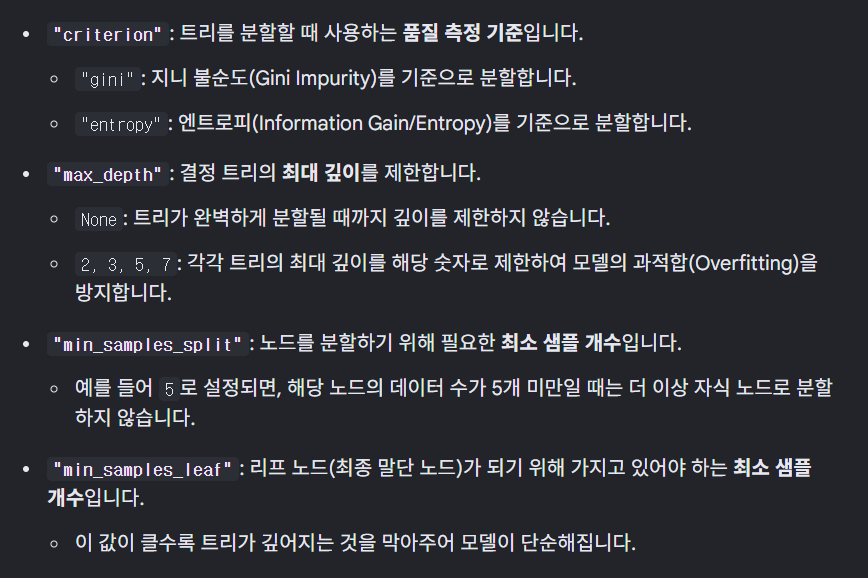


In [20]:
# GridSearchCV : 머신러닝 모델의 성능을 최적화하기 위해 최적의 하이퍼파라미터(Hyperparameter) 조합을 자동으로 찾아주는 알고리즘
# 격자(Grid)처럼 미리 정해둔 여러 값의 조합을 모두 교차 검증(CV, Cross Validation)하여 가장 좋은 결과를 내는 조합을 선별(Search)
from sklearn.model_selection import GridSearchCV

# 파라미터 설정값
parameters = {
    # 품질 측정 기준 : 지니계수, 엔트로피
    "criterion": ["gini", "entropy"],
    # 최대 깊이 제한 : 완벽 분할, 2, 3, 5, 7
    "max_depth": [None, 2, 3, 5, 7],
    # 노드를 분할하기 위한 최소 샘플 개수 : 2, 3, 5, 7
    "min_samples_split": [2, 3, 5, 7],
    # 리프 노드가 가져야하는 최소 샘플 개수 : 2, 3, 5, 7
    "min_samples_leaf": [1, 3, 5, 7],
}

# 하이퍼파라미터튜닝(모델, 하이퍼파라미터 후보군 딕셔너리, 5폴드교차검증)
grid_dt = GridSearchCV(dt_clf, param_grid=parameters, cv=5)
grid_dt.fit(X_train, y_train)

scores_df = pd.DataFrame(grid_dt.cv_results_)
scores_df[["params", "mean_test_score", "rank_test_score"]].sort_values(
    "rank_test_score", ascending=True
)

,params,mean_test_score,rank_test_score
115,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.893596,1
114,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.893596,1
113,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.893596,1
112,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.893596,1
83,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.893596,1
...,...,...,...
31,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.788424,153
24,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.781281,157
25,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.781281,157
26,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.781281,157


In [21]:
print("GridSearchCV 최적 파라미터:", grid_dt.best_params_)
print(f"GridSearchCV 최고 정확도: {grid_dt.best_score_:.4f}")

GridSearchCV 최적 파라미터: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
GridSearchCV 최고 정확도: 0.8936


In [23]:
model = grid_dt.best_estimator_
pred = model.predict(X_test)
accuracy_score(y_test, pred)

1.0

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred, target_names=wine.target_names))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        11
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        11

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



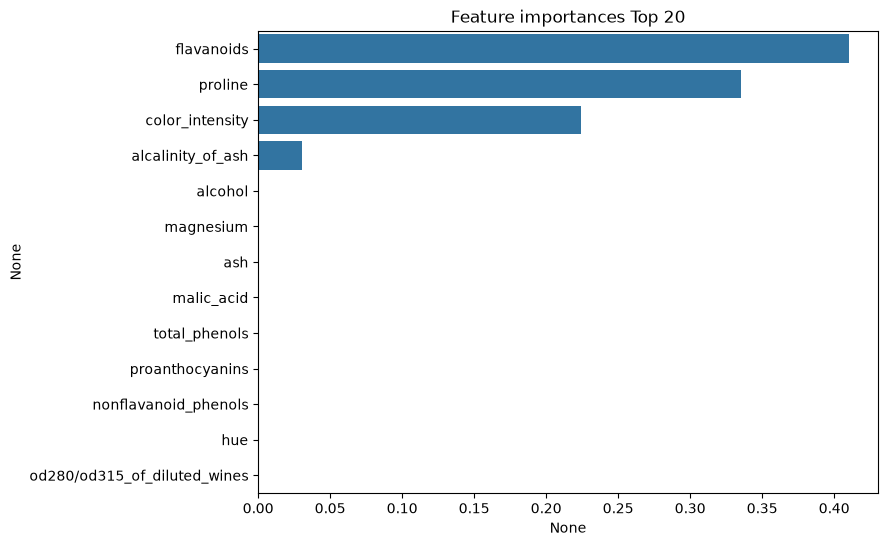

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

ftr_importances_values = model.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8, 6))
plt.title("Feature importances Top 20")
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

In [29]:
dt_clf.feature_importances_

array([0.02178286, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.09158213, 0.        , 0.05104208, 0.02964889,
       0.06019469, 0.32625068, 0.41949869])

In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 7), dpi=1200)
plot_tree(
    model,
    filled=True,
    feature_names=wine.feature_names,
    class_names=list(wine.target_names),
)

[Text(0.4230769230769231, 0.875, 'flavanoids <= 1.575\nentropy = 1.563\nsamples = 142\nvalue = [48, 57, 37]\nclass = class_1'),
 Text(0.15384615384615385, 0.625, 'color_intensity <= 3.825\nentropy = 0.803\nsamples = 49\nvalue = [0, 12, 37]\nclass = class_2'),
 Text(0.28846153846153844, 0.75, 'True  '),
 Text(0.07692307692307693, 0.375, 'entropy = 0.0\nsamples = 11\nvalue = [0, 11, 0]\nclass = class_1'),
 Text(0.23076923076923078, 0.375, 'alcalinity_of_ash <= 17.15\nentropy = 0.176\nsamples = 38\nvalue = [0, 1, 37]\nclass = class_2'),
 Text(0.15384615384615385, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1, 0]\nclass = class_1'),
 Text(0.3076923076923077, 0.125, 'entropy = 0.0\nsamples = 37\nvalue = [0, 0, 37]\nclass = class_2'),
 Text(0.6923076923076923, 0.625, 'proline <= 724.5\nentropy = 0.999\nsamples = 93\nvalue = [48, 45, 0]\nclass = class_0'),
 Text(0.5576923076923077, 0.75, '  False'),
 Text(0.5384615384615384, 0.375, 'proline <= 679.0\nentropy = 0.159\nsamples = 43\nvalue =

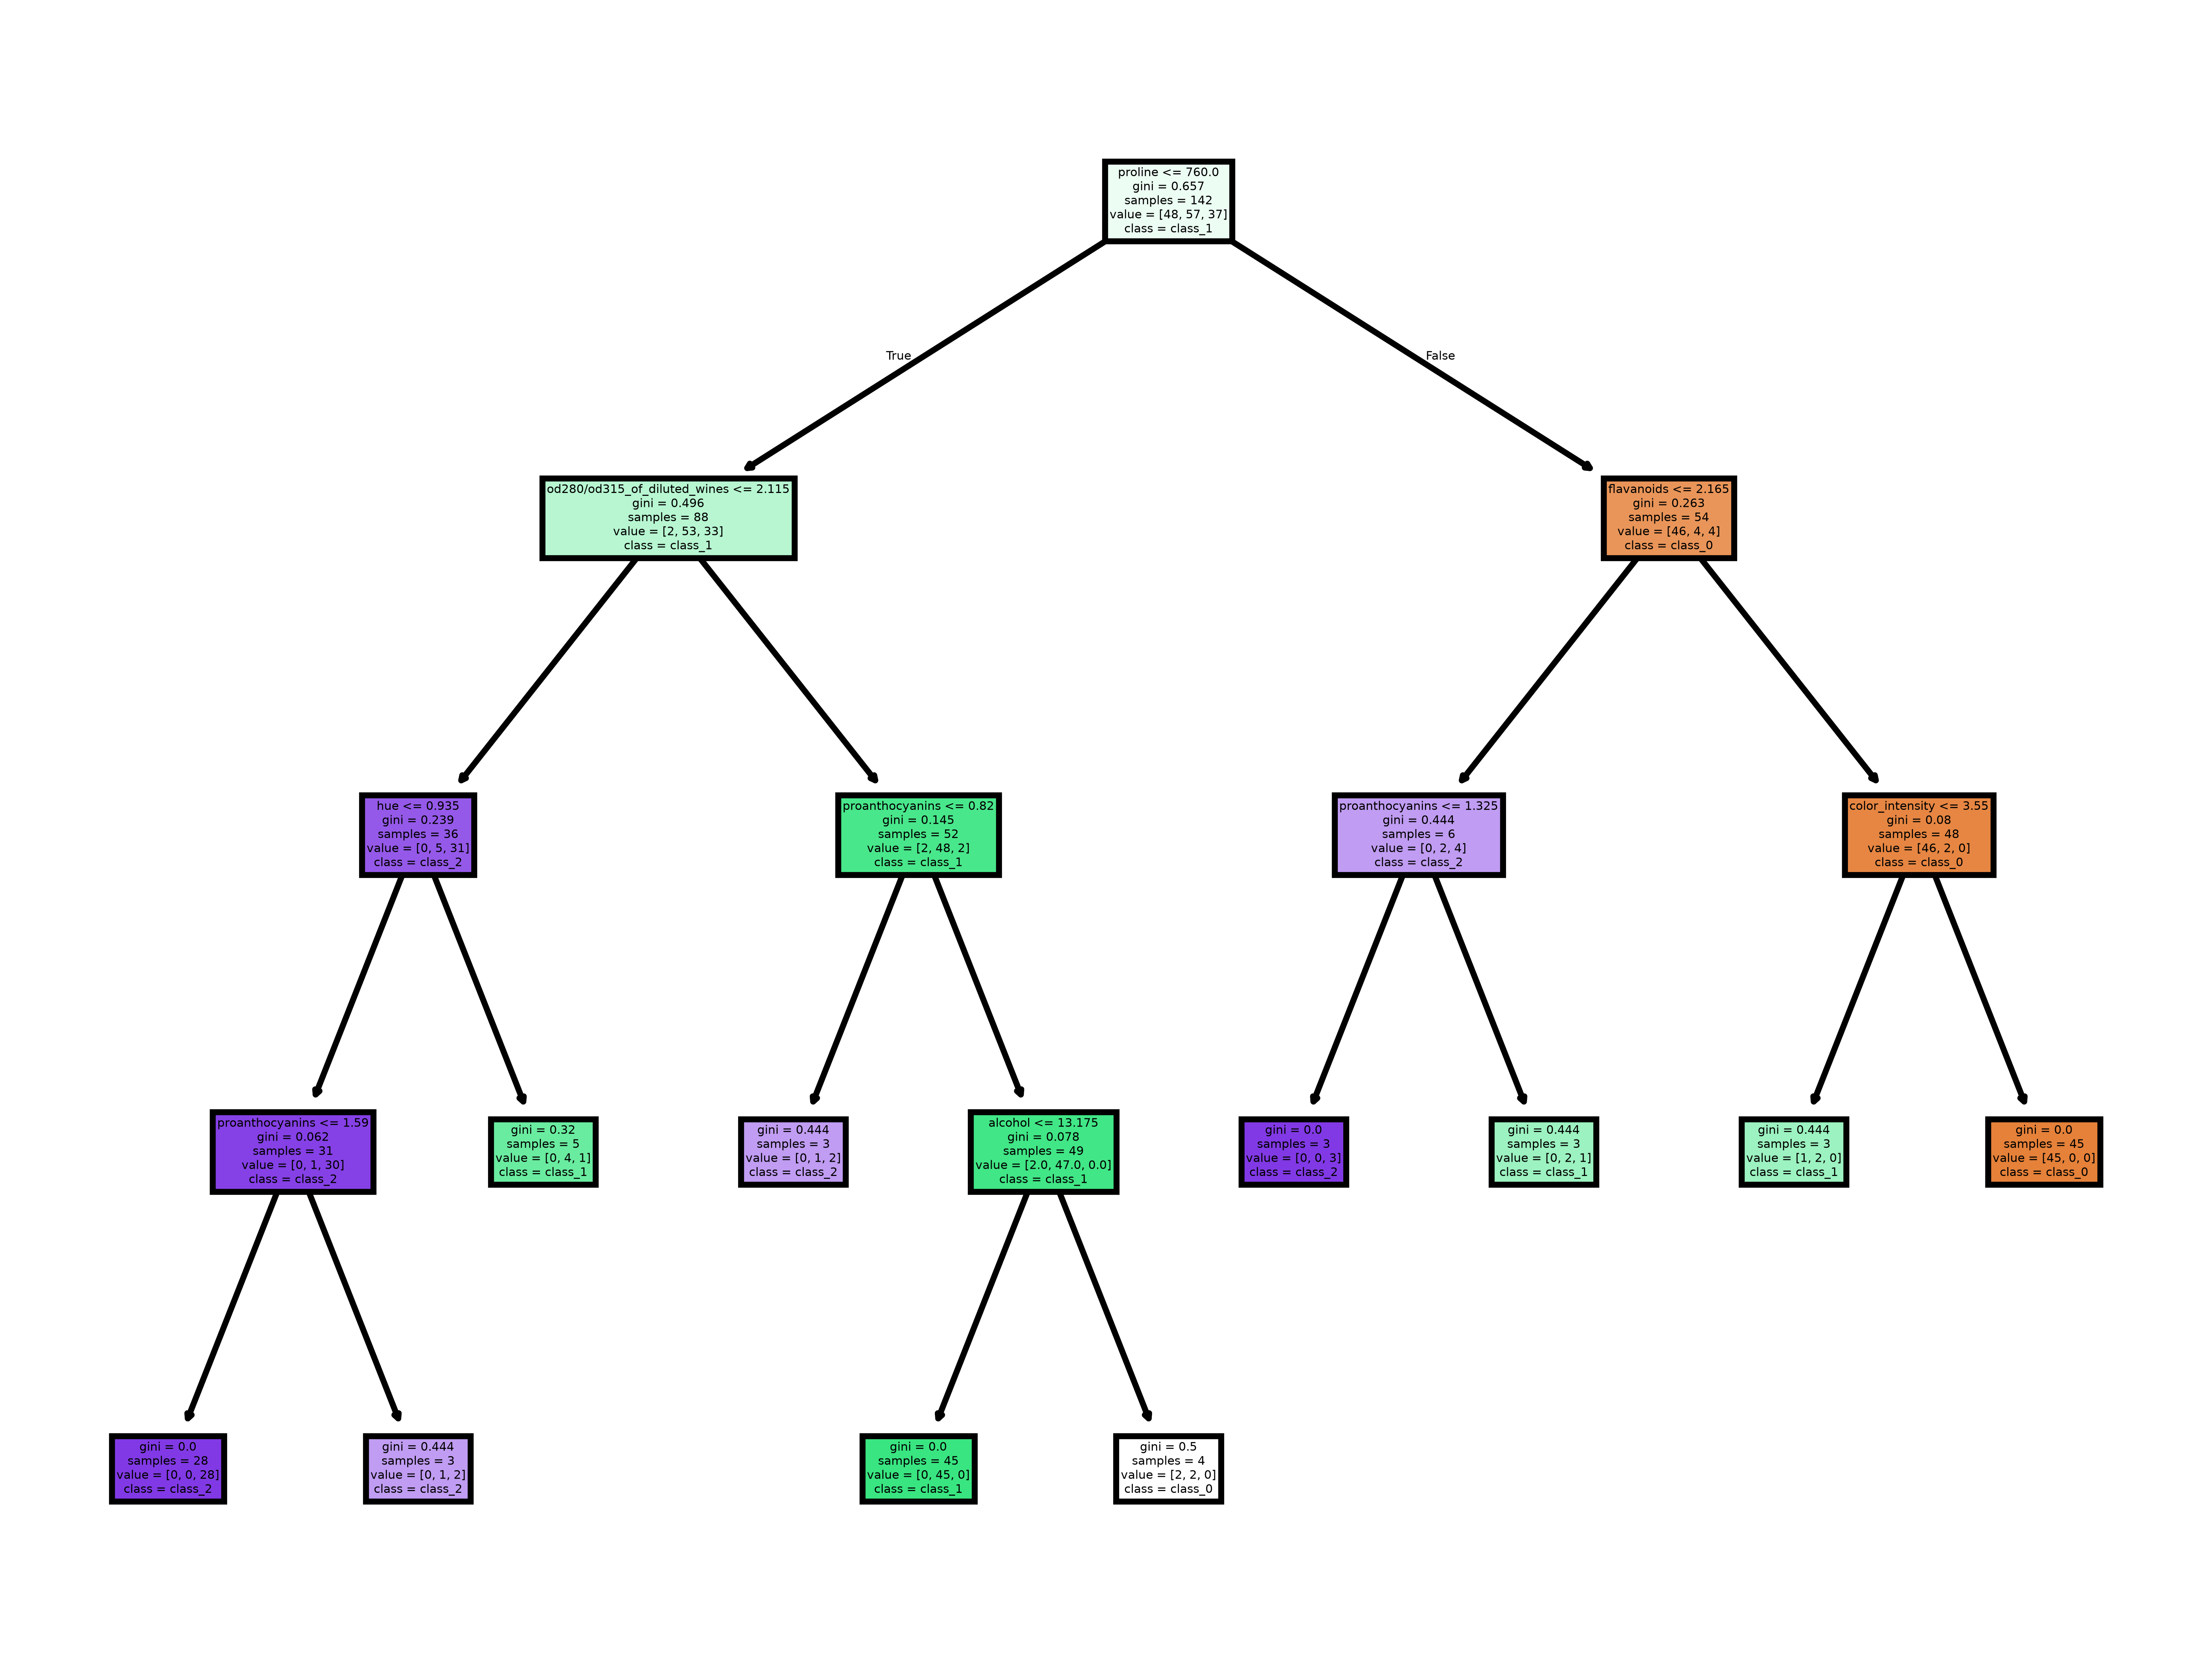

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_clf = DecisionTreeClassifier(min_samples_leaf=3)
dt_clf.fit(X_train, y_train)

plt.figure(dpi=1200)
plot_tree(
    dt_clf,
    filled=True,
    feature_names=wine.feature_names,
    class_names=list(wine.target_names),
)
plt.savefig("dt_msl3.png")
plt.show()

# 앙상블 기법 실습 (보팅 분류기)


In [32]:
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 유방암 데이터 사용
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


# 0 : 양성 (종양이 있다)

# 1 : 악성 종양 (종양이 심하다)


In [ ]:
# 로지스틱 회귀(분류) 모델 지정
lr_clf = LogisticRegression(solver="liblinear")

# 의사결정 트리(분류) 모델 지정
dt_clf = DecisionTreeClassifier(random_state=0)

# KNN 모델 지정
knn_clf = KNeighborsClassifier()

# 보팅 모델(분류) 지정 (로지스틱, 의사결정트리, 소프트방식으로)
vo_clf = VotingClassifier(
    estimators=[("LR", lr_clf), ("DT", dt_clf), ("KNN", knn_clf)], voting="soft"
)
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=0
)

vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)

print(f"Voting 분류기 정확도: {accuracy_score(y_test,pred):.4f}")

Voting 분류기 정확도: 0.9649


In [40]:
vo_clf.named_estimators

{'LR': LogisticRegression(solver='liblinear'),
 'DT': DecisionTreeClassifier(random_state=0),
 'KNN': KNeighborsClassifier()}

In [41]:
from sklearn.ensemble import RandomForestClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=0
)
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(f"랜덤 포레스트 정확도: {accuracy:.4f}")

랜덤 포레스트 정확도: 0.9649


In [44]:
# 의사결정나무 최소 100개
# 0.17205401인 컬럼이 가장 중요
rf_clf.feature_importances_

array([0.03699612, 0.01561296, 0.06016409, 0.0371452 , 0.0063401 ,
       0.00965994, 0.0798662 , 0.08669071, 0.00474992, 0.00417092,
       0.02407355, 0.00548033, 0.01254423, 0.03880038, 0.00379521,
       0.00435162, 0.00452503, 0.00556905, 0.00610635, 0.00528878,
       0.09556258, 0.01859305, 0.17205401, 0.05065305, 0.00943096,
       0.01565491, 0.02443166, 0.14202709, 0.00964898, 0.01001304])

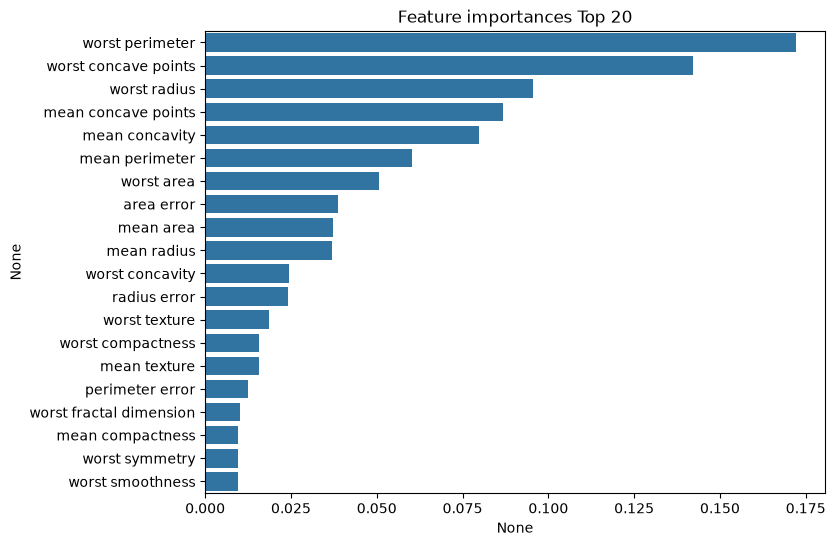

<Figure size 640x480 with 0 Axes>

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

ftr_importances_values = rf_clf.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=cancer.feature_names)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8, 6))
plt.title("Feature importances Top 20")
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()
plt.draw()

In [47]:
# 랜덤 포레스트의 각 의사결정나무들 출력
rf_clf.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=209652396),
 DecisionTreeClassifier(max_features='sqrt', random_state=398764591),
 DecisionTreeClassifier(max_features='sqrt', random_state=924231285),
 DecisionTreeClassifier(max_features='sqrt', random_state=1478610112),
 DecisionTreeClassifier(max_features='sqrt', random_state=441365315),
 DecisionTreeClassifier(max_features='sqrt', random_state=1537364731),
 DecisionTreeClassifier(max_features='sqrt', random_state=192771779),
 DecisionTreeClassifier(max_features='sqrt', random_state=1491434855),
 DecisionTreeClassifier(max_features='sqrt', random_state=1819583497),
 DecisionTreeClassifier(max_features='sqrt', random_state=530702035),
 DecisionTreeClassifier(max_features='sqrt', random_state=626610453),
 DecisionTreeClassifier(max_features='sqrt', random_state=1650906866),
 DecisionTreeClassifier(max_features='sqrt', random_state=1879422756),
 DecisionTreeClassifier(max_features='sqrt', random_state=1277901399),
 DecisionTree

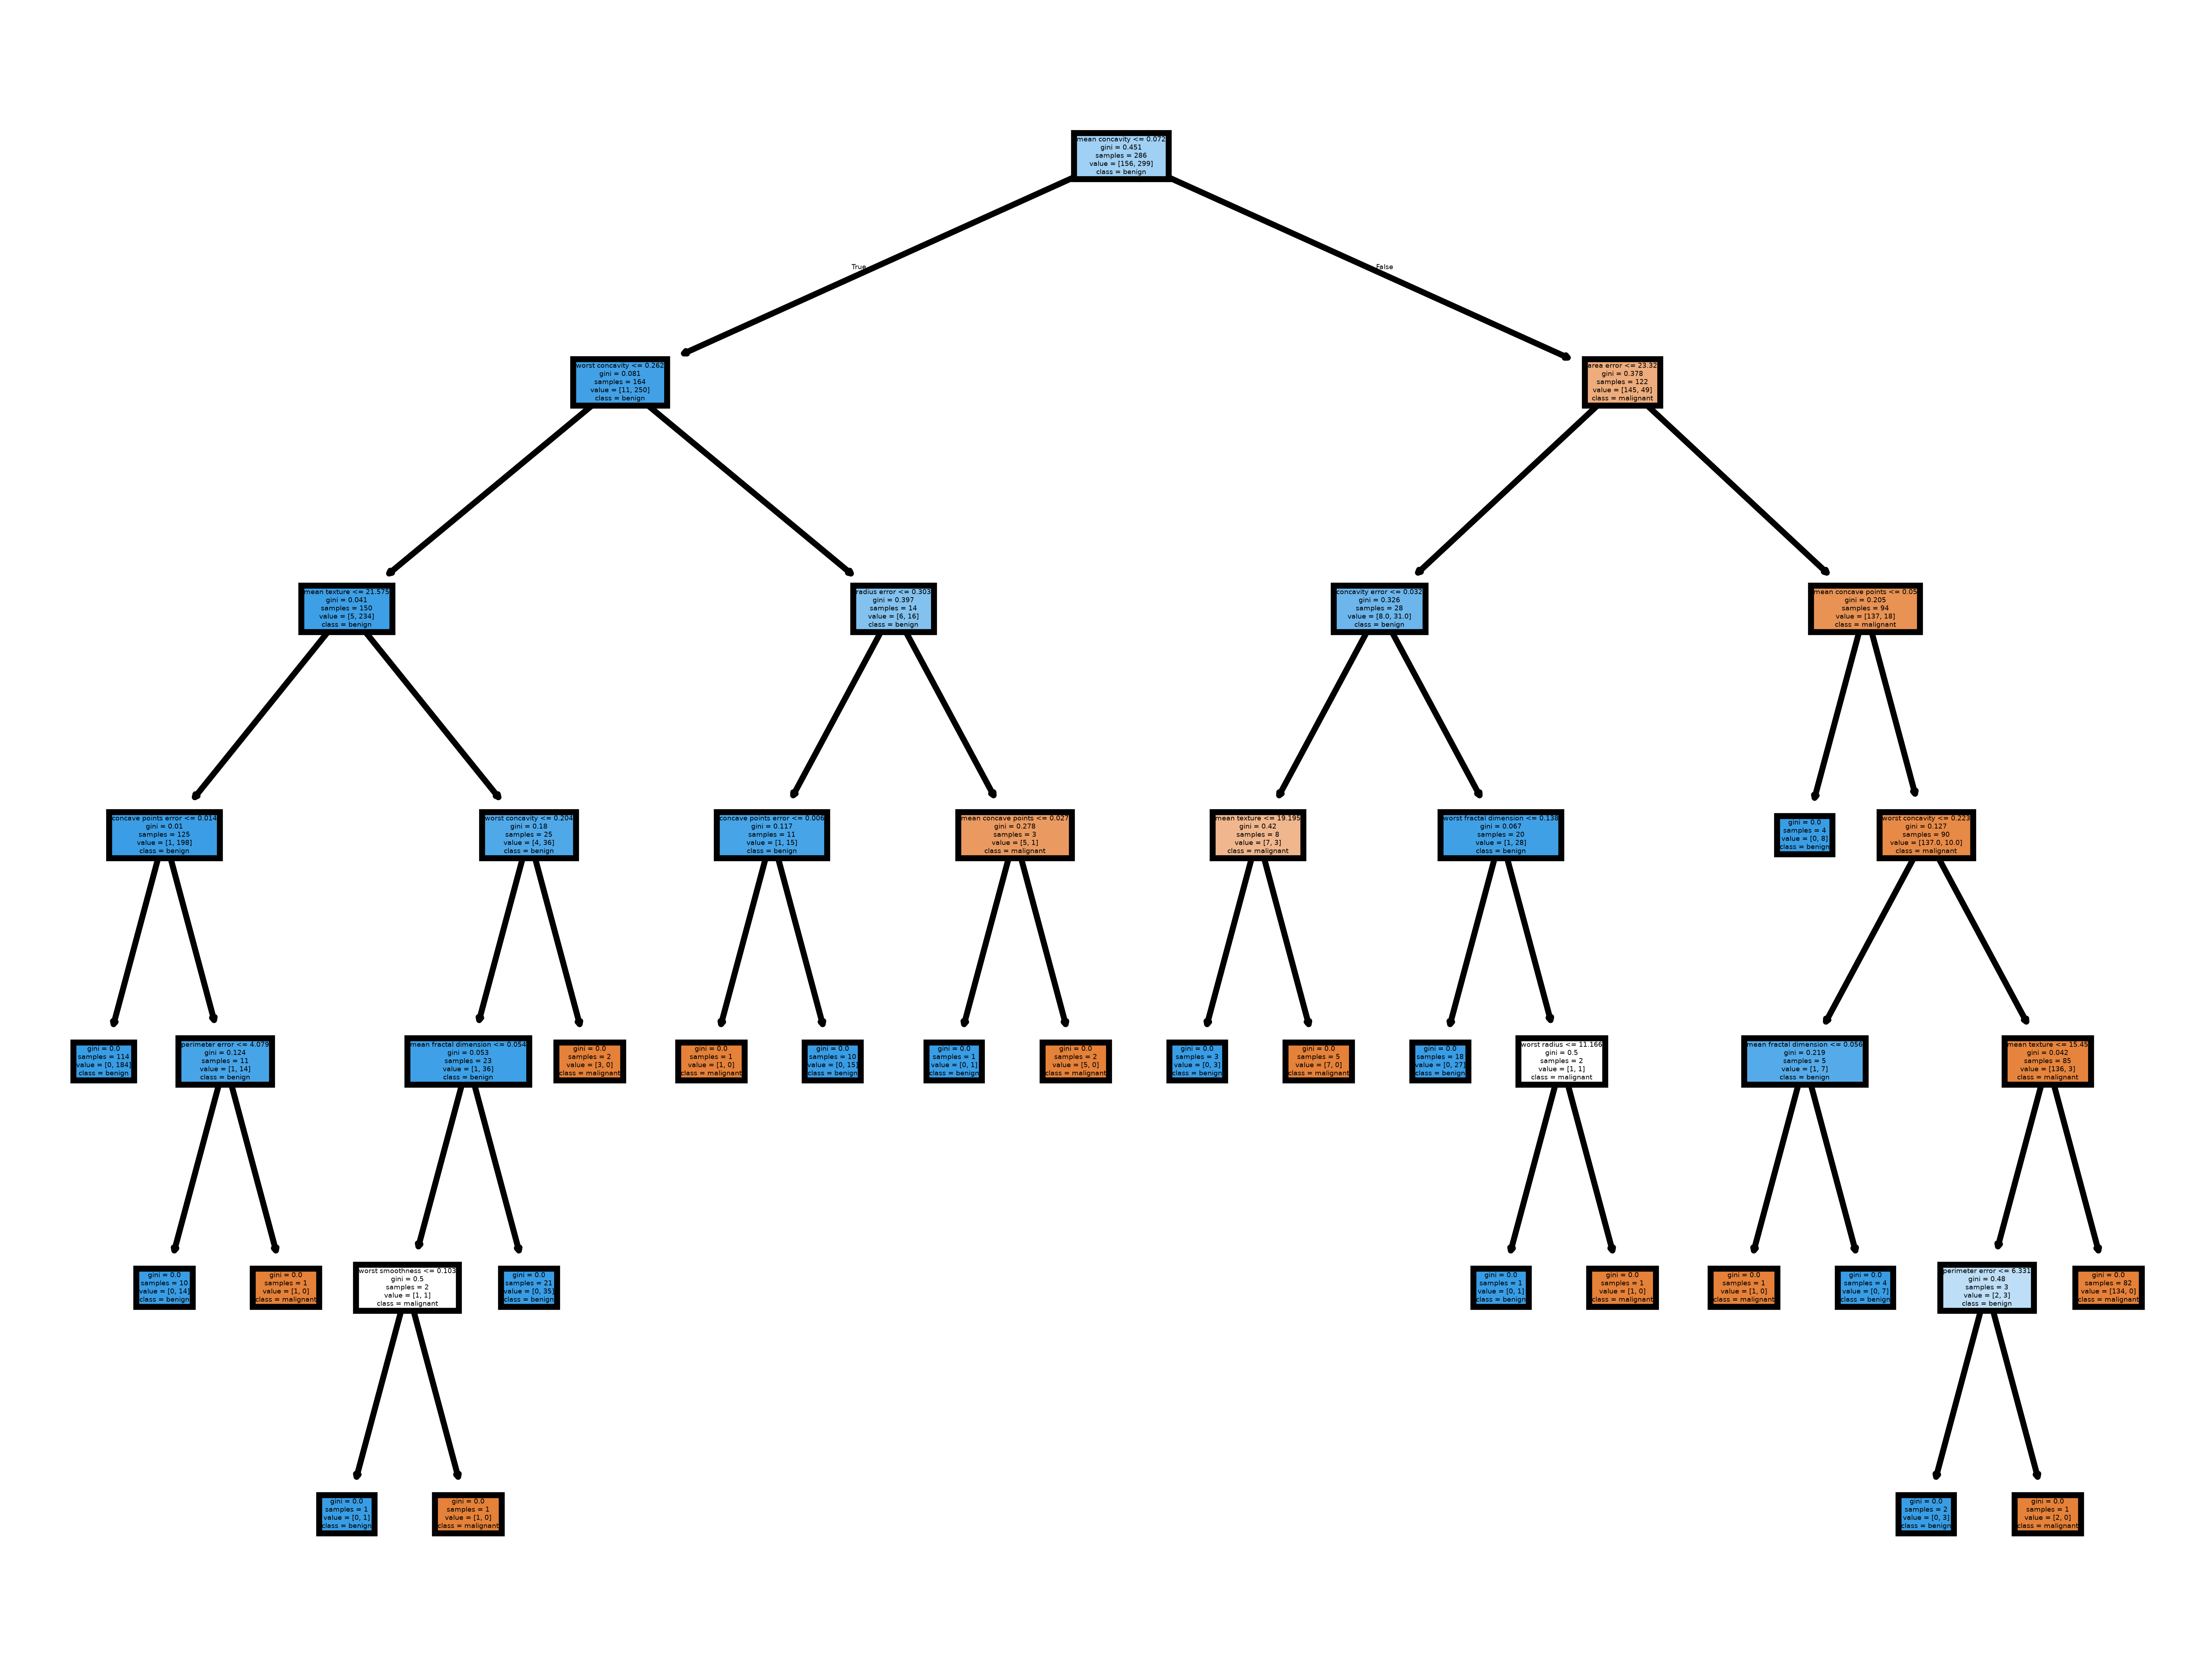

In [49]:
plt.figure(dpi=1200)
# 첫 번째 모델(첫 번째 의사결정나무) 그림 그리기
plot_tree(
    rf_clf.estimators_[0],
    filled=True,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names,
)
plt.savefig("rf_0dt.png")
plt.show()

In [51]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100],
    "max_depth": [6, 8, 10, 12],
    "min_samples_leaf": [8, 12, 18],
    "min_samples_split": [8, 16, 20],
}
rf_clf = RandomForestClassifier(random_state=0)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=3, n_jobs=-1, verbose=True)
grid_cv.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


KeyboardInterrupt: 

# GBM


In [53]:
# 원본 코드
from sklearn.ensemble import GradientBoostingClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=0
)
gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)
print(f"GBM 정확도: {gb_accuracy:.4f}")

GBM 정확도: 0.9649


In [56]:
# n_estimators 2배

from sklearn.ensemble import GradientBoostingClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=0
)

# n_estimators와 learning_rate 변경
gb_clf = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.01, random_state=0
)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)
print(f"GBM 정확도: {gb_accuracy:.4f}")

GBM 정확도: 0.9737


In [57]:
gb_clf.feature_importances_

array([5.50362744e-05, 1.24293450e-02, 1.24754366e-04, 3.75245516e-04,
       1.18973855e-02, 1.64672107e-04, 3.32466988e-04, 2.87943417e-01,
       8.89424800e-03, 1.43233957e-04, 3.30123146e-03, 1.21537312e-03,
       3.31263449e-03, 2.31480451e-02, 9.96738733e-04, 3.24760661e-05,
       5.99608007e-03, 3.52522415e-06, 4.55351466e-04, 1.38565949e-03,
       1.48079399e-02, 2.85115692e-02, 5.04086983e-02, 8.82299563e-02,
       9.96414910e-04, 5.25608976e-04, 1.19189837e-02, 4.41108457e-01,
       2.11179270e-04, 1.07427207e-03])

# XGBoost 실습


In [ ]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimator=400, learning_rate=0.1, eval_metric="logloss", early_stopping_rounds=10
)

In [80]:
# 학습 데이터와 테스트 데이터 생성
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=0
)

# 검증 데이터 생성
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0
)

In [81]:
xgb_wrapper.fit(X_train, y_train)
pred = xgb_wrapper.predict(X_test)

ValueError: Must have at least 1 validation dataset for early stopping.

In [85]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimator=1000,
    learning_rate=0.01,
    eval_metric="logloss",
    early_stopping_rounds=10,
)

evals = [(X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals)
pred = xgb_wrapper.predict(X_test)

[0]	validation_0-logloss:0.66713
[1]	validation_0-logloss:0.65961
[2]	validation_0-logloss:0.65226
[3]	validation_0-logloss:0.64509
[4]	validation_0-logloss:0.63809
[5]	validation_0-logloss:0.63124
[6]	validation_0-logloss:0.62443


[7]	validation_0-logloss:0.61767
[8]	validation_0-logloss:0.61107
[9]	validation_0-logloss:0.60466
[10]	validation_0-logloss:0.59834
[11]	validation_0-logloss:0.59228
[12]	validation_0-logloss:0.58622
[13]	validation_0-logloss:0.58037
[14]	validation_0-logloss:0.57455
[15]	validation_0-logloss:0.56894
[16]	validation_0-logloss:0.56336
[17]	validation_0-logloss:0.55802
[18]	validation_0-logloss:0.55254
[19]	validation_0-logloss:0.54728
[20]	validation_0-logloss:0.54218
[21]	validation_0-logloss:0.53705
[22]	validation_0-logloss:0.53207
[23]	validation_0-logloss:0.52695
[24]	validation_0-logloss:0.52210
[25]	validation_0-logloss:0.51727
[26]	validation_0-logloss:0.51257
[27]	validation_0-logloss:0.50776
[28]	validation_0-logloss:0.50305
[29]	validation_0-logloss:0.49855
[30]	validation_0-logloss:0.49400
[31]	validation_0-logloss:0.48967
[32]	validation_0-logloss:0.48529
[33]	validation_0-logloss:0.48112
[34]	validation_0-logloss:0.47697
[35]	validation_0-logloss:0.47299
[36]	validation_0

In [87]:
pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1])

In [88]:
accuracy_score(y_test, pred)

0.9649122807017544

In [89]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [92]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer_data = load_breast_cancer()
X_data = cancer_data.data
y_label = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_label, test_size=0.2, random_state=0
)

In [93]:
# 개별 ML 모델을 위한 Classifier 생성.
knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier(random_state=0)
ada_clf = AdaBoostClassifier(n_estimators=100)
# 최종 Stacking 모델을 위한 Classifier생성.
lr_final = LogisticRegression(solver="liblinear")

In [94]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    [("knn", knn_clf), ("rf", rf_clf), ("dt", dt_clf), ("ada", ada_clf)],
    final_estimator=lr_final,
)

In [95]:
stack.fit(X_train, y_train)
pred = stack.predict(X_test)
accuracy_score(y_test, pred)

0.9649122807017544

# 로지스틱 회귀분석(분류 모델)


In [101]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings

warnings.filterwarnings("ignore")
cancer = load_breast_cancer()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, cancer.target, test_size=0.3, random_state=0
)
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, pred_proba)
print(f"accuracy: {acc:.3f}, roc_auc:{auc:.3f}")

accuracy: 0.977, roc_auc:0.995


In [103]:
solvers = ["lbfgs", "liblinear", "newton-cg", "sag", "saga"]
for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, pred_proba)
print(f"solver: {solver}, accuracy: {acc:.3f}, roc_auc:{auc:.3f}")

solver: saga, accuracy: 0.982, roc_auc:0.995


In [104]:
from sklearn.model_selection import GridSearchCV

params = {
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2", "l1"],
    "C": [0.01, 0.1, 1, 5, 10],
}
lr_clf = LogisticRegression()
grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring="accuracy", cv=3)
grid_clf.fit(data_scaled, cancer.target)
print(f"최적 하이퍼 파라미터:{grid_clf.best_params_}")
print(f"최대 평균 정확도:{grid_clf.best_score_:.3f}")

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
최대 평균 정확도:0.979


In [ ]:
lr_clf = LogisticRegression(solver="sag", max_iter=500)
lr_clf.fit(X_train, y_train)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LogisticRegression(max_iter=500, solver='sag')

# KNN 실습


In [107]:
from sklearn.neighbors import KNeighborsClassifier

# metric(거리 계산하는 방식)이 중요 : 기본 값은 minkowski(민코프스키) 방식
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
pred = knn_clf.predict(X_test)
accuracy_score(y_test, pred)

0.9590643274853801